# Calidad del vino tinto

El siguiente documento tiene por propósito ilustrar paso a paso el análisis de calidad de vino, a través del uso de un modelo de clasificación basado en árboles de decisión.

## Conjunto de datos

Como parte fundamental del entrenamiento del modelo es adquirir un conjunto de datos que brinde información fundamental sobre las caracteristicas del vino tinto. A continuación se muestran los atributos obtenidos a partir de una prueba de elementos químicos:

1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol Output variable (based on sensory data):
12. quality (score between 0 and 10)




Este conjunto de datos esta diseñado para el análisis exploratorio de datos, tareas de clasificación y tareas de regresión en el campo del aprendizaje automático.

### Librerías

Las librerías *Pandas*, *NumPy*, *Matplotlib* y *Seaborn* son los pilares fundamentales del ecosistema de analítica de datos en Python. Juntas, cubren el ciclo completo de vida del dato: desde la ingesta y limpieza hasta la exploración visual y el modelado.

- **Pandas**: Es fundamental para la manipulación y análisis de datos. Te permite cargar el conjunto de datos (como el CSV de la calidad del vino), estructurarlo en DataFrames (tablas), realizar limpieza de datos (manejar valores faltantes, duplicados), transformar características (crear nuevas columnas, codificar variables categóricas) y preparar los datos para el modelado. Para árboles de decisión, pandas es crucial para organizar los datos de entrada y las etiquetas.

- **NumPy**: Es la base para la computación numérica en Python. Proporciona un objeto de arreglo multidimensional (ndarray) de alto rendimiento, junto con herramientas para trabajar con estos arreglos. Pandas se construye sobre NumPy. En el contexto de modelos, NumPy es esencial para realizar operaciones matemáticas eficientes sobre grandes conjuntos de datos, como cálculos de distancias, productos de matrices, o la gestión de los datos numéricos que alimentan el árbol de decisión.

- **Matplotlib**: Es una librería completa para la creación de visualizaciones estáticas, interactivas y animadas en Python. Es vital para la Exploración de Datos (EDA). Te permite crear gráficos de dispersión, histogramas, diagramas de caja, entre otros, para entender la distribución de las características del vino, identificar relaciones entre ellas y detectar posibles anomalías antes de entrenar el modelo. Con árboles de decisión, ayuda a visualizar las características más importantes o el rendimiento del modelo.

- **Seaborn**: Construido sobre Matplotlib, Seaborn proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. Facilita la creación de visualizaciones más complejas con menos código, como mapas de calor para correlaciones, gráficos de pares, o distribuciones por categorías. Es especialmente útil para la EDA en un conjunto de datos como el de la calidad del vino, permitiéndote explorar rápidamente cómo se relacionan las características químicas con la calidad del vino, lo cual puede influir en cómo construyes tu árbol de decisión.

In [1]:
# importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Análisis y pre-procesamiento del conjunto de datos

In [2]:
# Recuperación del conjunto de datos de las características del vino
ruta = '/content/drive/MyDrive/Datasets/winequality-red.csv'
df = pd.read_csv(ruta)

In [3]:
# Recuperación de características generales del conjunto
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Muestra del conjunto (los primeros 5 elementos)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Muestra del conjunto (los últimos 5 elementos)
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [11]:
# Verificar valores nulos en cada columna
null_counts = df.isnull().sum()
print("Conteo de valores nulos por columna:\n", null_counts)

Conteo de valores nulos por columna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [8]:
# Identificación de estadísticas descriptivas del conjunto
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


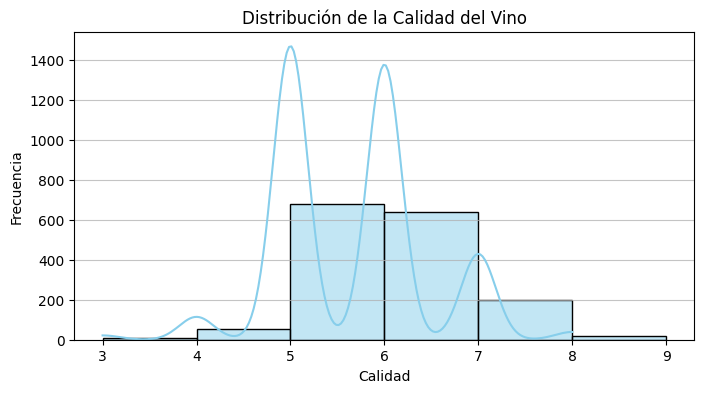

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df['quality'], bins=range(3, 10), kde=True, color='skyblue')
plt.title('Distribución de la Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Frecuencia')
plt.xticks(range(3, 10))
plt.grid(axis='y', alpha=0.75)
plt.show()

In [12]:
# Calcular la matriz de correlación
correlation_matrix = df.corr()

# Mostrar las correlaciones con la columna 'quality'
print("Correlaciones con la columna 'quality':\n", correlation_matrix['quality'].sort_values(ascending=False))

Correlaciones con la columna 'quality':
 quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


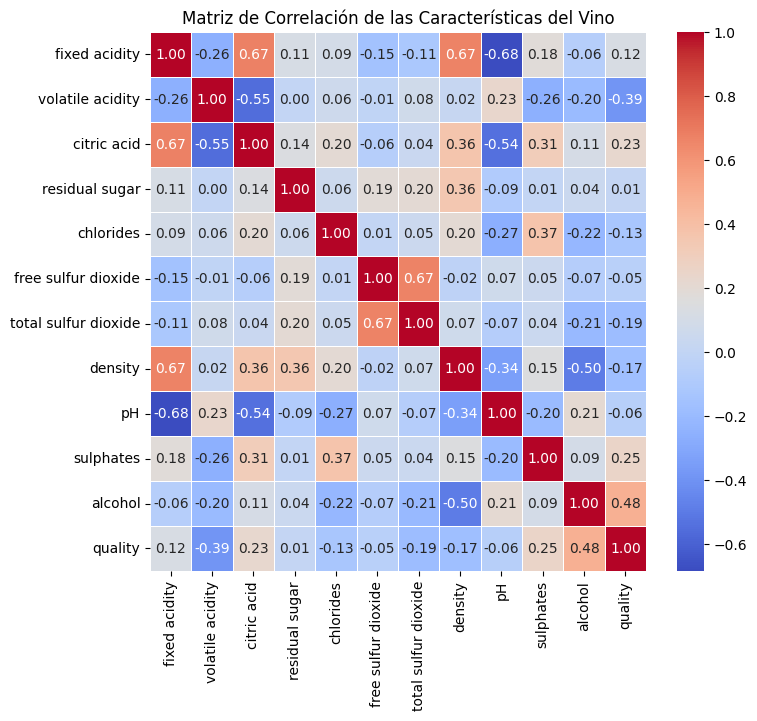

In [16]:
# Mapa de calor de la matriz de correlación de las características del vino
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de las Características del Vino')
plt.show()

De primera instancia se puede indeitificar que se cuenta con un conjunto de datos:
- Completo (todos los atributos suman la misma cantidad)
- Consistente (el tipo de datos se identifica de manera clara)
- Exactos (los datos modelan la calidad del vino)

## Modelado

### Preparación de Datos para el Modelado

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separar características (X) y la variable objetivo (y)
X = df.drop('quality', axis=1)  # Todas las columnas excepto 'quality' son características
y = df['quality']  # 'quality' es la variable objetivo

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos un 80% para entrenamiento y un 20% para prueba
# random_state asegura que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Columnas de características: {X.columns.tolist()}")

Tamaño del conjunto de entrenamiento: 1279 muestras
Tamaño del conjunto de prueba: 320 muestras
Columnas de características: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### Entrenamiento del Modelo de Árbol de Decisión

In [18]:
# Inicializar el clasificador de árbol de decisión
# Puedes ajustar parámetros como 'max_depth' o 'min_samples_leaf' para optimizar el modelo
dtc = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
dtc.fit(X_train, y_train)

print("Modelo de Árbol de Decisión entrenado exitosamente.")

Modelo de Árbol de Decisión entrenado exitosamente.


### Evaluación del Modelo

Precisión del modelo: 0.5594

Reporte de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.63      0.68      0.65       130
           6       0.55      0.53      0.54       132
           7       0.51      0.50      0.51        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.28      0.28      0.28       320
weighted avg       0.55      0.56      0.55       320


Matriz de Confusión:


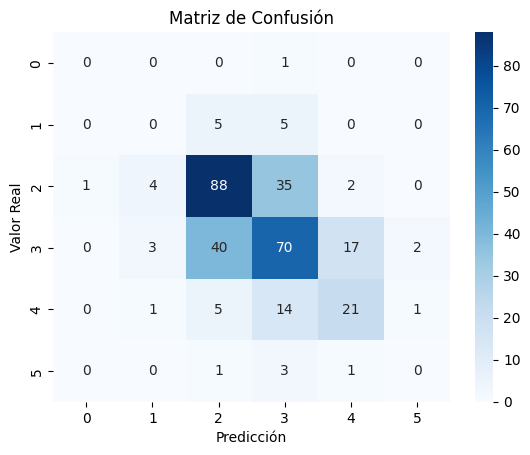

In [19]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = dtc.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.4f}")

# Mostrar el reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Mostrar la matriz de confusión
print("\nMatriz de Confusión:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

### Ajuste de Hiperparámetros con GridSearchCV

Para mejorar la precisión del modelo, podemos ajustar sus hiperparámetros. Esto se conoce como 'ajuste de hiperparámetros' o 'optimización de hiperparámetros'. Una técnica común es *GridSearchCV*, que busca sistemáticamente a través de múltiples combinaciones de hiperparámetros para encontrar el conjunto que arroja el mejor rendimiento.

In [20]:
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de hiperparámetros a buscar
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inicializar GridSearchCV
# 'cv=5' significa que usaremos validación cruzada de 5 pliegues
# 'scoring=\'accuracy\'' indica que la métrica a optimizar es la precisión
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Ejecutar la búsqueda en cuadrícula en los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Mostrar los mejores parámetros y la mejor puntuación
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación (precisión en CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor puntuación (precisión en CV): 0.6013


### Evaluación del Modelo con Hiperparámetros Optimizados

Precisión del modelo optimizado: 0.5594

Reporte de Clasificación del Modelo Optimizado:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.63      0.68      0.65       130
           6       0.55      0.53      0.54       132
           7       0.51      0.50      0.51        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.28      0.28      0.28       320
weighted avg       0.55      0.56      0.55       320


Matriz de Confusión del Modelo Optimizado:


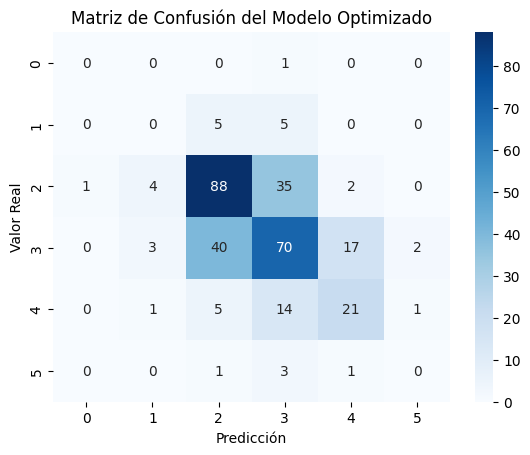

In [21]:
# Obtener el mejor modelo de la búsqueda en cuadrícula
best_dtc = grid_search.best_estimator_

# Realizar predicciones con el modelo optimizado
y_pred_optimized = best_dtc.predict(X_test)

# Calcular y mostrar la precisión del modelo optimizado
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Precisión del modelo optimizado: {accuracy_optimized:.4f}")

# Mostrar el reporte de clasificación del modelo optimizado
print("\nReporte de Clasificación del Modelo Optimizado:")
print(classification_report(y_test, y_pred_optimized))

# Mostrar la matriz de confusión del modelo optimizado
print("\nMatriz de Confusión del Modelo Optimizado:")
conf_matrix_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(conf_matrix_optimized, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo Optimizado')
plt.show()

### Entrenamiento y Evaluación del Modelo Random Forest

Un Random Forest es un modelo de conjunto que suele ofrecer mejor precisión que un solo árbol de decisión, ya que combina múltiples árboles para tomar decisiones. A continuación se implementa y evalúa un modelo de Random Forest para ver si se mejora la precisión.

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar el clasificador de Random Forest
# Puedes ajustar parámetros como n_estimators, max_depth, etc.
rf_classifier = RandomForestClassifier(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
rf_classifier.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

Modelo Random Forest entrenado exitosamente.


### Evaluación del Modelo Random Forest

Precisión del modelo Random Forest: 0.6594

Reporte de Clasificación del Modelo Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320


Matriz de Confusión del Modelo Random Forest:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


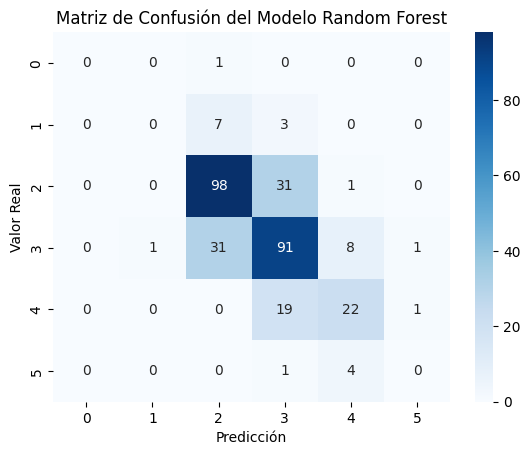

In [23]:
# Realizar predicciones sobre el conjunto de prueba con el modelo Random Forest
y_pred_rf = rf_classifier.predict(X_test)

# Calcular la precisión del modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Precisión del modelo Random Forest: {accuracy_rf:.4f}")

# Mostrar el reporte de clasificación del modelo Random Forest
print("\nReporte de Clasificación del Modelo Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Mostrar la matriz de confusión del modelo Random Forest
print("\nMatriz de Confusión del Modelo Random Forest:")
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo Random Forest')
plt.show()

### Ajuste de Hiperparámetros para Random Forest con GridSearchCV

In [26]:
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de hiperparámetros a buscar para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Inicializar GridSearchCV para Random Forest
# Usaremos 'rf_classifier' como estimador base
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Ejecutar la búsqueda en cuadrícula en los datos de entrenamiento
grid_search_rf.fit(X_train, y_train)

# Mostrar los mejores parámetros y la mejor puntuación
print(f"Mejores parámetros para Random Forest: {grid_search_rf.best_params_}")
print(f"Mejor puntuación (precisión en CV) para Random Forest: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros para Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor puntuación (precisión en CV) para Random Forest: 0.6928


### Evaluación del Modelo Random Forest con Hiperparámetros Optimizados

Precisión del modelo Random Forest optimizado: 0.6594

Reporte de Clasificación del Modelo Random Forest Optimizado:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.74      0.72       130
           6       0.61      0.71      0.66       132
           7       0.68      0.50      0.58        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320


Matriz de Confusión del Modelo Random Forest Optimizado:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


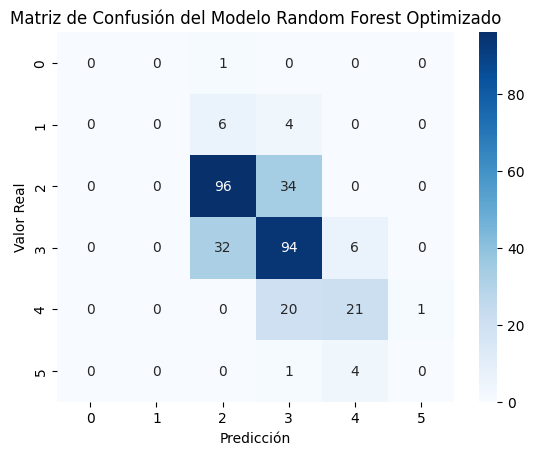

In [25]:
# Obtener el mejor modelo Random Forest de la búsqueda en cuadrícula
best_rf_classifier = grid_search_rf.best_estimator_

# Realizar predicciones con el modelo Random Forest optimizado
y_pred_rf_optimized = best_rf_classifier.predict(X_test)

# Calcular y mostrar la precisión del modelo Random Forest optimizado
accuracy_rf_optimized = accuracy_score(y_test, y_pred_rf_optimized)
print(f"Precisión del modelo Random Forest optimizado: {accuracy_rf_optimized:.4f}")

# Mostrar el reporte de clasificación del modelo Random Forest optimizado
print("\nReporte de Clasificación del Modelo Random Forest Optimizado:")
print(classification_report(y_test, y_pred_rf_optimized))

# Mostrar la matriz de confusión del modelo Random Forest optimizado
print("\nMatriz de Confusión del Modelo Random Forest Optimizado:")
conf_matrix_rf_optimized = confusion_matrix(y_test, y_pred_rf_optimized)
sns.heatmap(conf_matrix_rf_optimized, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo Random Forest Optimizado')
plt.show()

## Conclusiones

En resumen, el Random Forest se ha establecido como el modelo de mejor rendimiento hasta el momento, superando claramente al árbol de decisión. Sin embargo, es importante destacar que ambos modelos aún muestran dificultades con las clases de calidad menos representadas, resultando en advertencias de métricas indefinidas en el reporte de clasificación para estas clases. Esto indica que la escasez de datos para estas categorías de calidad más extremas sigue siendo un desafío clave que podría requerir técnicas adicionales como el sobremuestreo o el submuestreo, o incluso la redefinición de las clases de calidad si fuera apropiado para el problema de negocio.

## Exportación del Modelo Optimizado

Para poder utilizar el modelo entrenado en otras aplicaciones (por ejemplo, en un entorno de producción con Python o Node.js), es necesario serializarlo, es decir, guardarlo en un archivo. La librería `joblib` es muy eficiente para modelos de scikit-learn.

In [31]:
import joblib

# Definir la ruta donde se guardará el modelo
model_filename = 'random_forest_wine_quality_model.joblib'

# Guardar el modelo optimizado (best_rf_classifier) en un archivo
joblib.dump(best_rf_classifier, model_filename)

print(f"Modelo Random Forest optimizado guardado exitosamente en '{model_filename}'")

Modelo Random Forest optimizado guardado exitosamente en 'random_forest_wine_quality_model.joblib'


### Uso del Modelo Exportado

#### En Python

Para cargar y usar el modelo en otra aplicación Python, simplemente necesitas cargar el archivo `joblib` y luego puedes realizar predicciones con él. Asegúrate de que las características de entrada (`X_new`) tengan el mismo formato (número y orden de columnas) que se usó para entrenar el modelo.

```python
import joblib
import pandas as pd

# Cargar el modelo desde el archivo
loaded_model = joblib.load('random_forest_wine_quality_model.joblib')

# Ejemplo de nuevas características para predicción (asegúrate de que coincidan con las características de entrenamiento)
# Reemplaza estos valores con los datos reales de tu nueva muestra de vino
X_new = pd.DataFrame([[
    7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4
]], columns=X.columns) # X.columns debería ser accesible si estás en el mismo entorno o lo defines manualmente

# Realizar una predicción
prediction = loaded_model.predict(X_new)

# Recuerda que la predicción está 0-indexada, así que suma el valor mínimo original (3) para obtener la calidad real
original_min_quality = df['quality'].min() # Asumiendo que df todavía está disponible o sabes el mínimo
real_quality_prediction = prediction[0] + original_min_quality

print(f"La calidad predicha para la nueva muestra de vino es: {real_quality_prediction}")
```

#### En Node.js (Conceptual)

La exportación de un modelo de scikit-learn directamente a un formato que Node.js pueda consumir fácilmente es más compleja porque Node.js no tiene una implementación nativa de `joblib` o `pickle`. Generalmente, hay dos enfoques:

1.  **Reimplementar el modelo en JavaScript:** Si el modelo es lo suficientemente simple (como un árbol de decisión básico), podrías extraer sus reglas y reimplementarlas en JavaScript. Para un Random Forest, esto sería muy laborioso y propenso a errores.

2.  **Usar una API o Microservicio:** La forma más robusta y común es crear una API RESTful en Python que exponga el modelo. Tu aplicación Node.js entonces haría solicitudes HTTP a esta API con los datos de entrada, y la API Python respondería con la predicción. Este es el método preferido para modelos complejos.

    *   **Backend (Python):** Utilizarías frameworks como Flask, FastAPI o Django para cargar el modelo `joblib` y crear un endpoint que reciba los datos del vino, haga la predicción y devuelva el resultado en formato JSON.
    *   **Frontend/Backend (Node.js):** Tu aplicación Node.js enviaría los datos del vino a este endpoint Python usando bibliotecas como `axios` o la función `fetch`.

## Aplicaciones